<a href="https://colab.research.google.com/github/ji0-k/AI_26/blob/main/07_01_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 딥러닝의 시작 인공 신경망
# 레이어(Layer): 신경망은 층으로 쌓여 있 (입력층 -> 은닉층 -> 출력층)
# 손실 함수(Loss Function): "내 정답이 실제 정답이랑 얼마나 틀렸지?"를 계산하는 계산기
# 옵티마이저(Optimizer): 틀린 만큼 가중치(W)를 어떻게 수정할지 결정하는 '길잡이'

# 데이터 스케일링을 잊음: 신경망은 숫자가 너무 크면 학습을 잘 못 해요. 모든 숫자를 0~1 사이로 맞추는 과정이 필수입니다.
# 층을 무조건 깊게 쌓음: 층이 많다고 좋은 게 아니에요. 데이터가 적은데 층만 많으면
#                        오히려 공부를 '암기'해버리는 **과적합(Overfitting)**이 발생합니다.
# 결과값에 맞는 활성화 함수 미사용: * 예스/노(이중) 분류라면? 마지막에 sigmoid / 여러 개 중 하나(다중) 고르기라면? 마지막에 softmax


# MNIST 데이터 셋 : 손으로 쓴 0~9까지의 숫자로 이루어져 있음(https://docs.ultralytics.com/ko/datasets/classify/mnist/)
# MNIST는 60,000개의 훈련 이미지와 10,000개의 손글씨 숫자 테스트 이미지를 포함합니다.
# 데이터 세트는 28×28 픽셀 크기의 흑백 이미지로 구성됩니다.
# 이미지는 28×28 픽셀 바운딩 박스에 맞게 정규화되고 앤티앨리어싱 처리되어 회색조 레벨을 도입합니다.

# 패션 MNIST 데이터 셋 : 숫자대신 패션아이템으로 이루어짐
# https://www.kaggle.com/datasets 캐글에가면 연습용 데이터 셋이 많다.
# https://www.aihub.or.kr/ 국내에서 제공하는 연습용 데이터 셋 & 동영상강의

# 텐서플로 연산을 결정적으로 만듦
# 파이참에서 설치 pip install tensor flow

import tensorflow as tf

tf.keras.utils.set_random_seed(42) # 랜덤숫자고정
tf.config.experimental.enable_op_determinism() #텐서플로우 연산순서 일정하게 고정

from tensorflow import keras

(train_input, train_target),(test_input, test_target) = keras.datasets.fashion_mnist.load_data()
# load_data()가 (훈련용 입력, 훈련용 정답), (테스트용 입력, 테스트용 정답)로 나누어 반환

In [ ]:
# 데이터의 모양(shape)확인하기
print(train_input.shape,train_target.shape)
# 출력: (60000, 28, 28) (60000,)
# 60000개 이미지, 가세28*28픽셀, 60000개의 정답지(0~9)
print(test_input.shape, test_target.shape)
# 출력: (10000, 28, 28) (10000,)
# 10000개 이미지, 가세28*28픽셀, 10000개의 정답

In [ ]:
# 신경망 모델 만들기 전 바로 데이터 넣으면 X -> 전처리 필요
train_scaled = train_input / 255.0 # 255로 나누어 0~1 사이의 값으로 변환(실수형)

# 2차원을 1차원 배열로 펴기(flatten)
# 기본적 인공신경망 dense층은 1차원 배열만 입력 받을 수 있음
train_scaled = train_scaled.reshape(-1, 28*28)

In [ ]:
# 테스트 세트 미리 확인
# 데이터의 차원(shape)맞추기
# ValueError: Input 0 of layer dense is incompatible with the layer : 입력값과 기대값 모양 달라

In [ ]:
import matplotlib.pyplot as plt

# 훈련데이터의 앞부분 10개 가로 나열
fig,axs- plt.subplots(1,10,figsize=(10,10)) # 10*10 도화지준비, 서브플롯

for i in range(10):
  axs[i].imshow(train_input[i],cmap='gray_r')
  # i번째 그림창에 i번째 훈련데이터 그려줌
  # cmap='gray_r'은 'Gray Reverse'의 약자로, 검흰반
  axs[i].axis('on')
  # 3. 축 표시 설정: 'on'으로 하셨으니 가로/세로 0~28 눈금이 보일 거예요.
  # 깔끔하게 보려면 'off'
plt.show()

In [ ]:
print([train_target[i] for i in range(10)])
#[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]

In [ ]:
# gemini
# plt.subplots(1, 10)처럼 숫자를 직접 쓰는 경우, 20개를 보고 싶으면 1, 20으로 고치고 range(20)도 고쳐 번거로움

# n = 10   보고 싶은 개수를 변수로 지정
# fig, axs = plt.subplots(1, n, figsize=(n, 1)) # 개수에 맞춰 가로 길이를 조절
# for i in range(n):
#    axs[i].imshow(train_input[i], cmap='gray_r')
#    axs[i].axis('off') # 보통 데이터 확인할 땐 축을 끕니다.
#    변수로 지정도 가능

In [ ]:
import numpy as np
print(np.unique(train_target, return_counts=True))
# train_target 안의 고유한 값(0~9)과 각 값이 몇 번 나오는지 세어줍니다.
# 데이터 불균형 없는지 확인 -> 불균형 시 편향된 학습하게됨
# 출력 : (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [ ]:
# 주성분분석과 인공신경망 사이의 가교 역할 작업
# 인공신경망은 숫자들의 나열로 이미지데이터를 받아들임

# 1. 픽셀값 정규화 (Normalization) :보통 0~255 사이의 값을 가짐,너무커서 255로 나누어 0~1 사이의 값으로 만듦
train_scaled = train_input / 255.0

# 2. 2차원배열의 데이터 -> 1차원배열 펼치기(Flatten)
train_scaled = train_scaled.reshape(-1, 28*28) # -1은 모든 값

print(train_scaled.shape)

In [ ]:
# 로지스틱 회귀로 패션 아이템 분류하기

# 6만개 전체를 한번에 훈련하는 것보다 샘플 1개씩 꺼내서 모델을 훈련해보자.
# 확률적 경사 하강법 : SGDClassifier (분류용)
# SGDClassifier를 사용할 때 표준화 전처리된 데이터를 사용
# 확률적 경사 하강법은 여러 특성 중 기울기가 가장 가파른 방향을 따라 이동
# 만약 특성마다 값의 범위가 많이 다르면 올바르게 손실함수의 경사를 내려 올 수 없음



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

# 1. 모델 객체 생성
sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
# loss='log_loss' : 로지스틱 손실 함수를 사용하여 로지스틱 회귀모델 생성
# max_iter=5 : 전체데이터 5번 반복 학습 , 5에포크

# 2. 교차검증 (Cross Validation) 수행
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)

# 3. 평균 점수 출력
import numpy as np
print(np.mean(scores['test_score']))

#출력 : 0.8194166666666666

In [ ]:
# 인공신경망 (artificial 아티피셜 neural 뉴럴 network, ANN) 사용하여 아이템 분류 문제의 성능을 높혀 보자.

# 아이템 클래스 10개인 z_10 까지 계산하고 이를 바탕으로 클래스를 예측하기 때문에
# 신경망의 최종 값은 출력층(output Layer)

# 인공신경망의 z 값 계산하는 단위는 뉴런(Neuron)이라고 부름
# -> 선형계산을 진행 (대부분 유닛이라고 부름)

# 픽셀1 ~ 784번 픽셀까지를 입력층(input layer)이라고 부름 -> train_scaled

# z_1를 만들기 위해서 픽셀1인 x_1 에 곱해지는 가중치는 w_1.1 ..... 10개의 뉴런
# 사람 뇌에 있는 뉴런과 다름 (무언가를 만들어내는 것이 아니라 알고리즘의 일종)
# 확률적 경사 하강법을 사용한 로지스틱 회귀 모델이
# 가장 간단한 인공 신경망이라면 인공 신경망을 만들어도 성능이 좋아지지 않는다.
# 이미 인공신경망을 만들었다.
# 확률적 경사 하강법을 사용한 로지스틱 회귀는 가장 간단한 인공 신경망 모델이다.

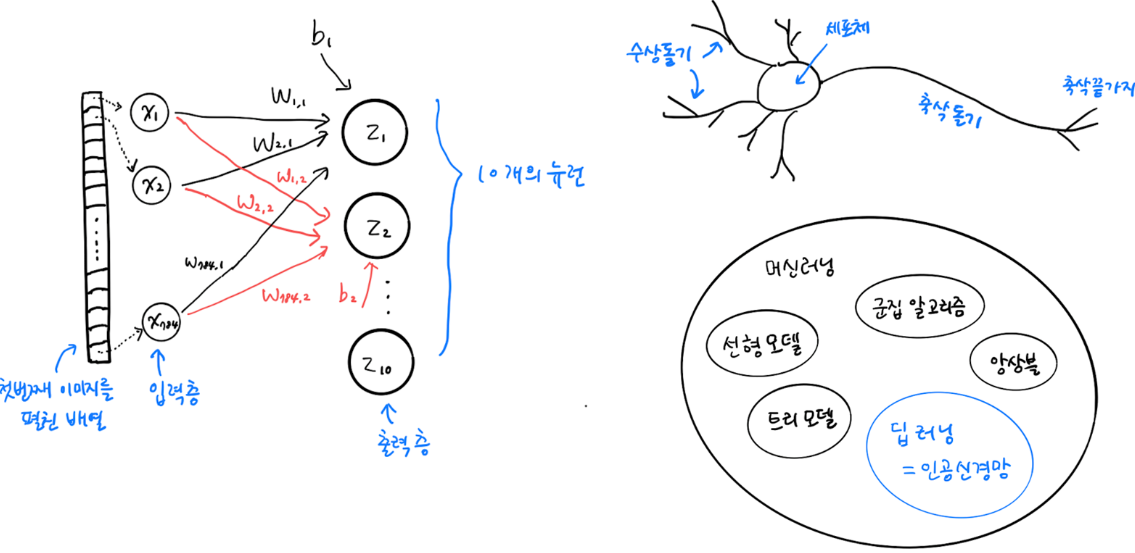

In [ ]:
# 로지스틱 회귀의 한계

# 로지스틱 회귀: 입력 데이터(x)에 가중치(w)를 곱해서 결과 도출, 단순구조
# 인공신경망 : 중간에 은닉층(hidden layer), 복잡한 패턴 꼬아서 한번더 해석

# 다음은 케라스(Keras)이용 딥러닝 모델 만들기
# 필요한 준비 검증세트나누기(train_test_split을 사용해 훈련데이터 일부 떼어놓기), 밀집층(dense)만들기(784입력받아 10개의 출력내는 층 설)

In [ ]:
# 텐서플로 TensorFlow

# Keras케라스와의 통합 , 복잡한 계산없이 레고 블록 쌓듯 모델 생성 가능
# 산업현장의 표준 , made google 안드로이드,서버,웹 배포 용이
# 텐서플로가 케라스 백엔드로 사용할 수 있다. -> 멀티-백엔드 케라스라고 부름

# 라이브러리의 양대 산맥
# 딥러닝 세상에는 구글의 TensorFlow와 메타(페이스북)의 PyTorch가 양대 산맥입니다.
# 텐서플로는 대규모 서비스(산업용)에 강하고, 파이토치는 연구와 논문 작성(학계)에 인기
# 하지만 초보자가 기본 원리를 배우기엔 텐서플로(케라스)가 아주 훌륭한 선택입니다.

# GPU의 중요성
# 딥러닝라이브러리는 단순한 곱셈 계산을 수만 번 반복하여 인공 신경망을 훈련함
# (GPU는 벡터와 행렬 연산으로 3D연산에 최적화 되어 있음
# 케라스 라이브러리는 직접 GPU연산을 수행하지 않는다.
# https://www.youtube.com/watch?v=AKob3yZT0I4
# 대신 GPU 연산을 수행하는 다른 라이브러리를 백엔드로 사용

# "로지스틱 회귀와 텐서플로(인공신경망)는 무엇이 다를까?"
# 정답: 층(Layer)의 유무
# 텐서플로는 입력과 출력 사이에 많은 층을 쌓아서 딥(Deep)러닝을 가능

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
# 인공 신경망으로 모델 만들기 : 앞에서 만든 train_scaled, train_target을 사용
# 인공 신경망에서는 교차 검증을 사용하지 않고 검증 세트를 별도로 덜어내어 사용
# 이유1 : 딥러닝 분야의 데이터 셋은 충분히 크기 때문에 검증 점수가 안정적
# 이유2 : 교차 검증을 수행하기에는 훈련시간이 너무 오래 걸림
# -> fit시간이 몇시간, 며칠이 걸릴 수도 있음

In [ ]:
from sklearn.model_selection import train_test_split

# 훈련세트를 훈련세트8: 검증세트2 로 나누기, 모의고사 필요

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)
# train_scaled: 진짜 학습에 사용할 데이터 (48,000개)
# val_scaled: 학습 중간에 모델의 실력을 점검할 '검증용' 데이터 (12,000개) 모의고사용
# train_target & val_target: 각각에 대응하는 정답지들

print(train_scaled.shape, train_target.shape) #출력:(48000, 784) (48000,)
print(val_scaled.shape, val_target.shape)     #출력:(12000, 784) (12000,)

# 왜 검증세트 만들었는가?
# 과대적합(Overfitting) 방지: 모델이 훈련 데이터의 아주 사소한 특징(노이즈)까지 다 외워버리면,
#                             정작 새로운 데이터(테스트 세트)가 들어왔을 때 엉뚱한 답을 내놓습니다.
# 검증 세트는 학습 중에 "너 지금 너무 훈련 데이터만 외우고 있는 거 아니야?"라고 감시하는 역할을 합니다.

# 하이퍼파라미터 튜닝: 층을 몇 층 쌓을지, 노드를 몇 개로 할지 결정할 때
#                     기준이 되는 것이 바로 이 검증 세트의 점수입니다.

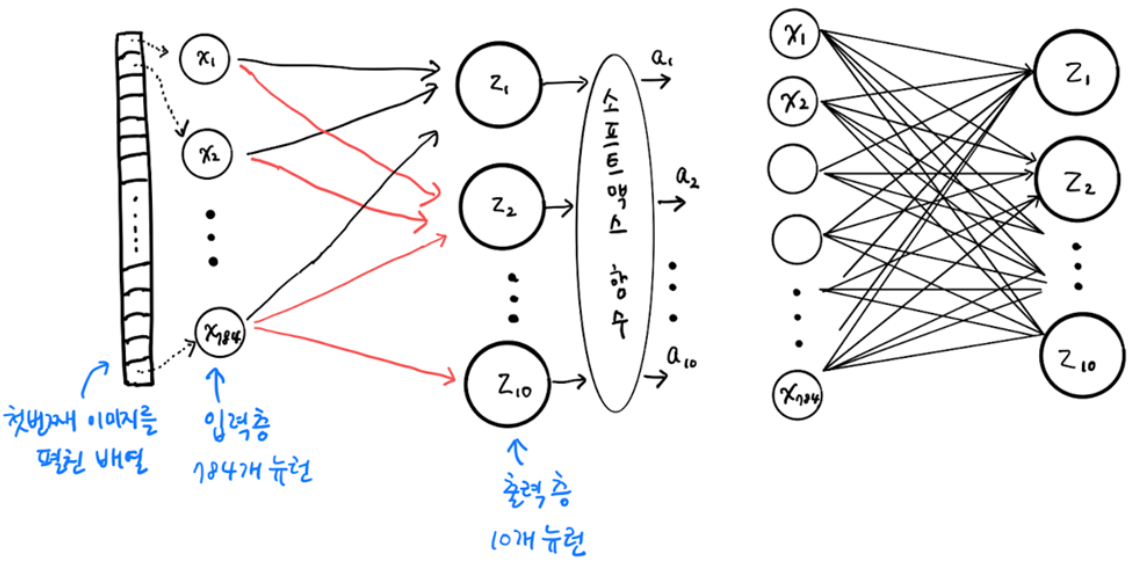

In [ ]:
# 딥러닝에서는 다양한 종류의 층을 추가하는 식으로 모델을 만듬.
# 이번 장에서는 Dense 층을 사용. 밀집층, 완전연결층. fully connteced layer

# 10개의 유닛 -> 타켓이 10개
# 다중 분류이므로 활성화 함수는 소프트맥스(숫자들을 모두 더해서 **1(100%)**이 되도록 마법),
# 입력 값은 784개의 원소로 이루어진 1차원 배열(픽셀28*28).
# 이진 분류이면 시그모이드 함수를 사용함

# 케라스는 첫 번째 층에 입력 크기를 넣어야 합니다.
# 그 다음에 추가되는 층은 자동으로 계산되기 때문에 넣을 필요 없음.
# 케라스 모델은 Sequential(순차적) 클래스로 만듬

# 인공신경망의 오른쪽에 놓인 층을 만듬,
# 10개의 패션아이템을 분류하기 위해서 10개의 뉴런으로 구성

# 케라스의 레이어 패키지 안에는 다양한 층이 존재,
# 가장 기본이 되는 층이 밀집층(dense layer)
# 밀집층(dense layer) : 784개의 픽셀과 10개의 뉴런이 모두 연결된 선이라는 뜻
# 총 784 * 10 = 7840개의 연결 선이 있다.

# 이런 층을 뉴런이 모두 연결하고 있어 완전 연결층(fully connected layer)라고 부름

In [ ]:
dense = keras.layers.Dense(10, activation='softmax', input_shape(784,))